In [2]:
import pandas as pd
import os
import random

# Write the folder name only once
data_folder = "res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0"

# Choose how many tickers to use
# Set to None if you want all tickers
MAX_TICKERS = 1

# Make ticker selection reproducible
TICKER_SEED = 42

# Build paths from that
csv_path = os.path.join(data_folder, "labels.csv")

# Load csv
df = pd.read_csv(csv_path)

# Convert dates
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Use end_date as the observation date for splitting
df["date"] = df["end_date"]

# --------------------------------------------------
# LIMIT NUMBER OF TICKERS EARLY IN THE FILE
# --------------------------------------------------
all_tickers = sorted(df["ticker"].unique())
print(f"Total tickers available before filtering: {len(all_tickers)}")

if MAX_TICKERS is not None:
    if MAX_TICKERS > len(all_tickers):
        raise ValueError(
            f"MAX_TICKERS={MAX_TICKERS} is larger than the number of available tickers ({len(all_tickers)})."
        )

    rng = random.Random(TICKER_SEED)
    selected_tickers = rng.sample(all_tickers, MAX_TICKERS)
    selected_tickers = sorted(selected_tickers)

    df = df[df["ticker"].isin(selected_tickers)].copy()
    print(f"Using {len(selected_tickers)} tickers: {selected_tickers[:10]}{' ...' if len(selected_tickers) > 10 else ''}")

print(f"Rows after ticker filtering: {len(df)}")
print(df["ticker"].nunique(), "unique tickers remain")

print(df.head())
print(df.info())
print(df["label"].value_counts())

Total tickers available before filtering: 1
Using 1 tickers: ['AAPL']
Rows after ticker filtering: 8
1 unique tickers remain
                                          image_path ticker start_date  \
0  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-10-23   
1  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-10-30   
2  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-11-06   
3  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-11-13   
4  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-11-20   

    end_date  close_now  close_future  label       date  
0 2024-10-29     233.67        223.45      0 2024-10-29  
1 2024-11-05     223.45        224.23      1 2024-11-05  
2 2024-11-12     224.23        228.28      1 2024-11-12  
3 2024-11-19     228.28        235.06      1 2024-11-19  
4 2024-11-26     235.06        243.01      1 2024-11-26  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

In [3]:
import os

df["file_exists"] = df["image_path"].apply(os.path.exists)

print(df["file_exists"].value_counts())

# Keep only rows where the image exists
df = df[df["file_exists"]].copy()

file_exists
True    8
Name: count, dtype: int64


Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

In [4]:
df = df.sort_values("date").reset_index(drop=True)
print(len(df))

8


Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [5]:
unique_dates = sorted(df["date"].unique())

n_dates = len(unique_dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (5, 9)
Val shape: (1, 9)
Test shape: (2, 9)


In [15]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())

print("\nLabel balance:")
print("Train:\n", ((train_df["label"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str).str.replace(".", ",", regex=False) + "%"))
print("Val:\n",   ((val_df["label"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str).str.replace(".", ",", regex=False) + "%"))
print("Test:\n",  ((test_df["label"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str).str.replace(".", ",", regex=False) + "%"))


Date ranges:
Train: 2024-10-29 00:00:00 to 2024-11-26 00:00:00
Val:   2024-12-04 00:00:00 to 2024-12-04 00:00:00
Test:  2024-12-11 00:00:00 to 2024-12-18 00:00:00

Number of tickers:
Train: 1
Val:   1
Test:  1

Label balance:
Train:
 label
0    20,0%
1    80,0%
Name: proportion, dtype: object
Val:
 label
1    100,0%
Name: proportion, dtype: object
Test:
 label
1    100,0%
Name: proportion, dtype: object


In [16]:
train_label_balance = train_df["label"].mean()
val_label_balance   = val_df["label"].mean()
test_label_balance  = test_df["label"].mean()

print("\nLabel balance:")
print(f"Train up: {train_label_balance:.1%}")
print(f"Val up:   {val_label_balance:.1%}")
print(f"Test up:  {test_label_balance:.1%}")


Label balance:
Train up: 80.0%
Val up:   100.0%
Test up:  100.0%


In [7]:
import sys
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python311\python.exe


In [8]:
import os
import re

folder_name = os.path.basename(data_folder)

match = re.match(r"res_(\d+)_(color|grayscale)", folder_name)
if not match:
    raise ValueError(f"Could not read resolution/color mode from folder name: {folder_name}")

IMG_RESOLUTION = int(match.group(1))
COLOR_MODE = match.group(2)

PIL_MODE = "RGB" if COLOR_MODE == "color" else "L"
INPUT_CHANNELS = 3 if COLOR_MODE == "color" else 1

print("IMG_RESOLUTION:", IMG_RESOLUTION)
print("COLOR_MODE:", COLOR_MODE)
print("PIL_MODE:", PIL_MODE)
print("INPUT_CHANNELS:", INPUT_CHANNELS)

IMG_RESOLUTION: 96
COLOR_MODE: color
PIL_MODE: RGB
INPUT_CHANNELS: 3


Image batch shape: torch.Size([5, 3, 96, 96])
Label batch shape: torch.Size([5])
First 10 labels: tensor([1, 0, 1, 1, 1])


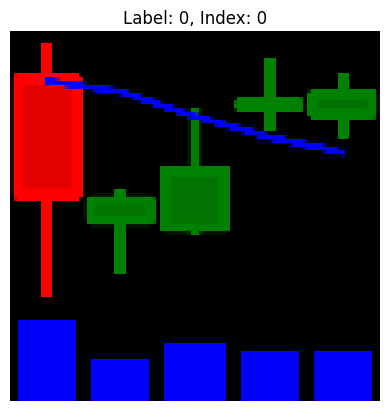

In [9]:
import pandas as pd
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert(PIL_MODE) # Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, idx

basic_transform = transforms.Compose([
    transforms.Resize((IMG_RESOLUTION, IMG_RESOLUTION)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Test one batch
images, labels, idx = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Show one example image
image, label, idx = train_dataset[0]
img_np = image.permute(1, 2, 0).numpy()

plt.imshow(img_np)
plt.title(f"Label: {label}, Index: {idx}")
plt.axis("off")
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [10]:
import torch
import sys

print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python311\python.exe
Torch version: 2.10.0+cpu
CUDA available: False
Torch CUDA version: None
GPU count: 0


In [11]:
import os
import torch
import torch.nn as nn


class JiangI5RGB(nn.Module):
    """
    Jiang-inspired CNN adapted to your exact use case:
    - only I5 (5 lookback days)
    - predicts 5 days ahead (R5)
    - input images are 224x224 RGB, like in your supervisor's setup

    Important thesis note:
    This is NOT an exact line-by-line copy of Jiang.
    It is a Jiang-style adaptation for your RGB image pipeline.
    """

    def __init__(self, num_classes=2, input_channels=3):
        super().__init__()

        self.features = nn.Sequential(
            # ============================================================
            # BLOCK 1
            # ============================================================

            nn.Conv2d(
                in_channels=input_channels,
                # MODIFIED FROM JIANG:
                # Jiang's original images are black/white and effectively 2D sparse chart images.
                # Your images are RGB, so we must use 3 input channels.
                out_channels=32,
                # MODIFIED FROM JIANG:
                # Jiang starts with 64 filters in the first block for the I5 model.
                # I reduce this to 32 to make training lighter and faster for your thesis.
                kernel_size=(5, 3),
                # DIRECTLY FROM JIANG:
                # Jiang uses 5x3 convolution filters because the chart images are sparse
                # in the vertical dimension.
                stride=(1, 1),
                # MODIFIED FROM JIANG:
                # Jiang uses special first-layer vertical stride/dilation settings
                # for sparse raw images.
                # Because your images are already rendered 224x224 RGB charts,
                # I keep standard stride=(1,1) for a simpler and more stable implementation.
                padding=(2, 1),
                # NOT SPECIFICALLY FROM JIANG:
                # This padding keeps output size roughly stable before pooling.
                bias=False
                # NOT SPECIFICALLY FROM JIANG:
                # When BatchNorm comes right after Conv, bias is usually unnecessary.
            ),

            nn.BatchNorm2d(32),
            # DIRECTLY FROM JIANG:
            # Jiang states that batch normalization is applied between
            # convolution and nonlinear activation.

            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            # DIRECTLY FROM JIANG:
            # Jiang explicitly uses leaky ReLU as the activation.

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # DIRECTLY FROM JIANG:
            # Jiang uses 2x1 max-pooling because of the image structure.

            # ============================================================
            # BLOCK 2
            # ============================================================

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                # MODIFIED FROM JIANG:
                # Jiang doubles filters by layer and would go 64 -> 128 for I5.
                # Here I go 32 -> 64 to keep the model lighter.
                kernel_size=(5, 3),
                # DIRECTLY FROM JIANG:
                # Same 5x3 convolution choice as Jiang.
                stride=(1, 1),
                # MODIFIED / PRACTICAL:
                # Again, standard stride rather than Jiang's sparse-first-layer trick.
                padding=(2, 1),
                bias=False
            ),

            nn.BatchNorm2d(64),
            # DIRECTLY FROM JIANG

            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            # DIRECTLY FROM JIANG

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # DIRECTLY FROM JIANG
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            # MODIFIED FROM JIANG:
            # Jiang's original model flattens the final feature map directly
            # and then uses a fully connected layer.
            #
            # I replace that with AdaptiveAvgPool2d((1,1)) because your 224x224 RGB
            # images would otherwise create a much larger classifier head.
            # This keeps training cheaper and cleaner while preserving the CNN logic.

            nn.Flatten(),
            # PARTLY JIANG-LIKE:
            # Jiang also flattens before the final classifier,
            # but here flatten happens after adaptive pooling.

            nn.Dropout(0.5),
            # DIRECTLY FROM JIANG:
            # Jiang uses 50% dropout on the fully connected layer.

            nn.Linear(64, num_classes)
            # MODIFIED FROM JIANG:
            # Jiang's final FC input is much larger because he flattens the whole
            # final CNN output. Here the input is only 64 because of adaptive pooling.
            #
            # num_classes=2 matches your binary Up/Down setup.
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                # DIRECTLY FROM JIANG:
                # Jiang uses Xavier initialization.
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
                    # PRACTICAL CHOICE:
                    # Zero bias init is standard and harmless here.

    def forward(self, x):
        x = self.features(x)
        # Pass image through the 2 Jiang-style CNN blocks.

        x = self.classifier(x)
        # Convert learned feature maps into final Up/Down class scores.

        return x
        # Return raw logits.
        # CrossEntropyLoss will apply the proper classification logic internally.


def count_parameters(model):
    # NOT FROM JIANG:
    # This is just a helper so you can see how large the model is.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    # NOT FROM JIANG:
    # Standard PyTorch training function.
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    # NOT FROM JIANG:
    # Standard PyTorch evaluation function.
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = JiangI5RGB(num_classes=2, input_channels=INPUT_CHANNELS).to(device)
print("Trainable params:", count_parameters(model))

criterion = nn.CrossEntropyLoss()
# DIRECTLY FROM JIANG:
# Jiang treats this as a binary classification problem and uses cross-entropy loss.

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# PARTLY FROM JIANG, PARTLY MODIFIED:
# Adam is directly from Jiang.
# The learning rate is MODIFIED.
# Jiang uses 1e-5, but here I use 1e-4 because this is a lighter adapted model
# and in practice that is often easier to train with your setup.
# If training is unstable, try 1e-5.

num_epochs = 15
# MODIFIED / PRACTICAL:
# Jiang uses early stopping, so the exact epoch count is less important.
# 15 is just a reasonable upper limit.

best_val_loss = float("inf")

patience = 3
# MODIFIED FROM JIANG:
# Jiang stops after 2 consecutive non-improving epochs.
# I use 3 to make training a bit less sensitive to noisy validation loss.

patience_counter = 0

model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")
# NOT FROM JIANG:
# Just your local save path and filename.

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  Early stopping triggered.")
            break
            # DIRECTLY JIANG-LIKE IDEA, MODIFIED IMPLEMENTATION:
            # Jiang uses early stopping after 2 bad epochs.
            # Here we do the same idea, but with patience=3.

Using device: cpu
Trainable params: 32482
Epoch 1/15
  Train loss: 0.4647 | Train acc: 1.0000
  Val   loss: 0.6815 | Val   acc: 1.0000
  Saved best model.
Epoch 2/15
  Train loss: 0.7750 | Train acc: 0.6000
  Val   loss: 0.7012 | Val   acc: 0.0000
Epoch 3/15
  Train loss: 0.8059 | Train acc: 0.2000
  Val   loss: 0.7169 | Val   acc: 0.0000
Epoch 4/15
  Train loss: 0.4994 | Train acc: 0.8000
  Val   loss: 0.7299 | Val   acc: 0.0000
  Early stopping triggered.


In [12]:
import os
import torch
import torch.nn.functional as F

# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JiangI5RGB(num_classes=2, input_channels=INPUT_CHANNELS).to(device)
model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

model.eval()

# Reset index so dataset idx matches dataframe row
test_df = test_df.reset_index(drop=True)

# Create empty column for predicted probability of "up"
test_df["pred_prob_up"] = None

with torch.no_grad():
    for images, labels, indices in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Option A: convert 2 logits to probabilities
        probs_up = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        for i, idx in enumerate(indices.numpy()):
            test_df.loc[idx, "pred_prob_up"] = float(probs_up[i])

# Optional: also create predicted class from 0.5 threshold
test_df["pred_label"] = (test_df["pred_prob_up"].astype(float) >= 0.5).astype(int)

# Save file
predictions_path = os.path.join(data_folder, "test_predictions.csv")
test_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)
print(test_df.head())

Test loss: 0.6698
Test acc:  1.0000
Saved predictions to: res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0\test_predictions.csv
                                          image_path ticker start_date  \
0  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-12-05   
1  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...   AAPL 2024-12-12   

    end_date  close_now  close_future  label       date  file_exists  \
0 2024-12-11     246.49        248.05      1 2024-12-11         True   
1 2024-12-18     248.05        259.02      1 2024-12-18         True   

  pred_prob_up  pred_label  
0     0.512103           1  
1     0.511471           1  


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, confusion_matrix

y = test_df["label"].to_numpy()
p = test_df["pred_prob_up"].astype(float).to_numpy()
pred = (p >= 0.5).astype(int)

print("Pred prob summary:")
print("min =", p.min())
print("max =", p.max())
print("mean =", p.mean())
print("share below 0.5 =", np.mean(p < 0.5))
print("share above/equal 0.5 =", np.mean(p >= 0.5))

print("\nClassification metrics:")
print("Accuracy         =", accuracy_score(y, pred))
print("Balanced accuracy=", balanced_accuracy_score(y, pred))
print("AUC              =", roc_auc_score(y, p))
print("Log loss         =", log_loss(y, p))
print("\nConfusion matrix:")
print(confusion_matrix(y, pred))

Pred prob summary:
min = 0.5114709138870239
max = 0.5121026039123535
mean = 0.5117867588996887
share below 0.5 = 0.0
share above/equal 0.5 = 1.0

Classification metrics:
Accuracy         = 1.0
Balanced accuracy= 1.0
AUC              = nan


c:\Users\morte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\morte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


ValueError: y_true contains only one label (1). Please provide the true labels explicitly through the labels argument.

In [13]:
base_p = train_df["label"].mean()
base_pred_prob = np.full_like(y, fill_value=base_p, dtype=float)
base_pred_class = np.ones_like(y) if base_p >= 0.5 else np.zeros_like(y)

print("Baseline constant prob =", base_p)
print("Baseline accuracy      =", (y == base_pred_class).mean())
print("Baseline log loss      =", log_loss(y, base_pred_prob))

Baseline constant prob = 0.5481183567940247
Baseline accuracy      = 0.5371120107962213
Baseline log loss      = 0.6906342591363168


Random test index: 0
True label:      1
Predicted label: 1
Prob down:       0.4879
Prob up:         0.5121


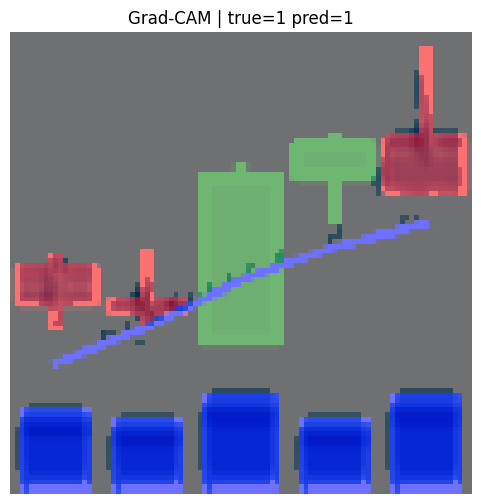

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ---- Grad-CAM helper ----
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[0, class_idx]

        self.model.zero_grad()
        score.backward()

        activations = self.activations[0]   # [C, H, W]
        gradients = self.gradients[0]       # [C, H, W]

        weights = gradients.mean(dim=(1, 2))  # [C]

        cam = torch.zeros(activations.shape[1:], device=activations.device)
        for c, w in enumerate(weights):
            cam += w * activations[c]

        cam = F.relu(cam)

        if cam.max() > 0:
            cam = cam / cam.max()

        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        return cam.squeeze().cpu().numpy(), output.detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


# ---- choose last conv layer ----
target_layer = model.features[4]   # good default for your current CNN
gradcam = GradCAM(model, target_layer)

# ---- pick 1 random test image ----
idx = random.randint(0, len(test_dataset) - 1)
image, label, row_idx = test_dataset[idx]
input_tensor = image.unsqueeze(0).to(device)

# ---- generate Grad-CAM ----
cam, logits = gradcam.generate(input_tensor)
probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
pred = int(np.argmax(probs))

# ---- print info ----
print(f"Random test index: {idx}")
print(f"True label:      {label}")
print(f"Predicted label: {pred}")
print(f"Prob down:       {probs[0]:.4f}")
print(f"Prob up:         {probs[1]:.4f}")

# ---- prepare image for plotting ----
img = image.detach().cpu().permute(1, 2, 0).numpy()
img = img - img.min()
if img.max() > 0:
    img = img / img.max()

# optional threshold to highlight only stronger regions
cam_plot = cam.copy()
cam_plot[cam_plot < 0.40] = 0.0

# ---- show original + Grad-CAM overlay ----
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.imshow(cam_plot, cmap="Blues", alpha=0.45)
plt.title(f"Grad-CAM | true={label} pred={pred}")
plt.axis("off")
plt.show()

gradcam.remove_hooks()